### 🔹 Objectif

Vous allez entraîner votre **premier modèle de classification automatique** pour prédire le **genre littéraire du roman** à partir des **profils lexicaux de personnages**.

Le jeu de données `df_personnages_POLICIER_SENTIMENT_genred` contient :

* 1000 colonnes de fréquences de mots (Bag of Words) ;
* une colonne `"genre"` indiquant si le roman est *policier* ou *sentimental*.

### 🔹 Tâche

1. **Extraire les données**

   * Les variables explicatives `X` correspondent à toutes les colonnes sauf `"genre"`.
   * Les étiquettes `y` correspondent à la colonne `"genre"`.

2. **Diviser les données**

   * Créez un *jeu d’entraînement* (80 %) et un *jeu de test* (20 %) avec `train_test_split`.
   * Option : Utilisez `stratify=y` pour garder la même proportion de genres dans chaque ensemble.

3. **Entraîner un classifieur SVM**

   * Utilisez `LinearSVC` de `scikit-learn`.
   * Fixez `class_weight="balanced"` pour compenser les déséquilibres éventuels.

4. **Évaluer les performances**

   * Prédisez sur le jeu de test.
   * Affichez le `classification_report` et la `ConfusionMatrixDisplay`.
   * Interprétez les résultats : le modèle reconnaît-il mieux un genre que l’autre ? Pourquoi ?
   * Étudier les erreurs du modèle
   * Cross-validation !

5. **Mettre les mains dans le cambouis**
    * A. Tester la sensibilité du modèle - Refaites le `train_test_split` avec différentes proportions (30 %, 40 %) ou différents `random_state`
    * B. Limiter le vocabulaire - Refaites l’expérience avec seulement les 100 mots les plus fréquents (au lieu de 1000). Comparez les résultats.
    * C. Comparer plusieurs modèles SVM - kernel `Polynomial, RBF`
    * D. Filtrer les personnages peu décrits - (Supprimez ceux dont la somme des fréquences est inférieure à un seuil (ex. 0.02).)
    * E. Explorer les coefficients du modèle - Pour un `LinearSVC`, les coefficients indiquent l’importance des mots. Récupérez `clf.coef_` et affichez les 10 mots les plus discriminants pour chaque genre

👉 *Objectif : comprendre le pipeline complet “entraîner → prédire → évaluer”.*


In [1]:
import pandas as pd

In [2]:
df_personnages_POLICIER_SENTIMENT = pd.read_csv("BoW_personnages_Genres.csv", index_col="Unnamed: 0")

In [3]:
df_personnages_POLICIER_SENTIMENT.head(2)

,avoir,dire,voir,faire,vouloir,pouvoir,savoir,aller,aimer,regarder,...,avis,adosser,médecin,défaire,décourager,armer,délaisser,déplaire,creuser,genre
1931_Simenon-Georges_La-Guinguette-a-deux-sous.book --- james,0.069343,0.023723,0.016423,0.031022,0.025547,0.014599,0.023723,0.023723,0.012774,0.041971,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,policier
1931_Simenon-Georges_La-Guinguette-a-deux-sous.book --- maigret,0.059730,0.032755,0.038536,0.009634,0.017341,0.017341,0.017341,0.011561,0.003854,0.040462,...,0.003854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,policier


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

Best params: {'clf__C': 10}
CV best macro-F1: 0.7594

Classification report (test):

              precision    recall  f1-score   support

    policier      0.750     0.900     0.818        20
 sentimental      0.875     0.700     0.778        20

    accuracy                          0.800        40
   macro avg      0.812     0.800     0.798        40
weighted avg      0.812     0.800     0.798        40



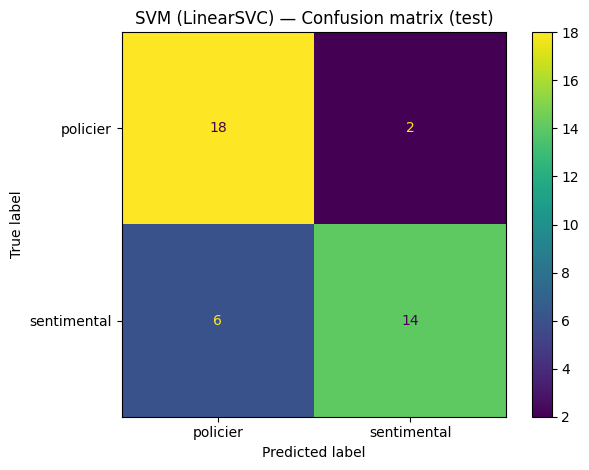

In [5]:
# 1) X / y from your dataframe
df = df_personnages_POLICIER_SENTIMENT.copy()
assert "genre" in df.columns, "Missing 'genre' column."

X = df.drop(columns=["genre"]).fillna(0.0).values
y = df["genre"].values

# 2) Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=54
)

# 3) Pipeline + grid-search (LinearSVC)
pipe = Pipeline([
    ("clf", LinearSVC(class_weight="balanced"))
])

param_grid = {
    "clf__C": [0.1, 1, 3, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("CV best macro-F1:", round(gs.best_score_, 4))

# 4) Final evaluation on the held-out test set
y_pred = gs.predict(X_test)
print("\nClassification report (test):\n")
print(classification_report(y_test, y_pred, digits=3))

# 5) Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("SVM (LinearSVC) — Confusion matrix (test)")
plt.tight_layout()
plt.show()


In [7]:

# 0) Get feature names (columns except "genre")
feature_names = df.drop(columns=["genre"]).columns.to_numpy()

# 1) Retrieve the trained LinearSVC from the best estimator
best_clf = gs.best_estimator_.named_steps["clf"]
classes = best_clf.classes_
W = best_clf.coef_            # shape: (n_classes or 1, n_features)

# 2) Handle binary case where coef_ may have shape (1, n_features)
#    If only one row, it's the separator for classes[1] vs classes[0].
if W.shape[0] == 1 and len(classes) == 2:
    W = np.vstack([ -W[0], W[0] ])  # row 0 for classes[0], row 1 for classes[1]

# 3) Build a nice table of top words per class (top positive weights)
topk = 10
rows = []
for i, cls in enumerate(classes):
    w = W[i]
    idx = np.argsort(w)[-topk:][::-1]            # indices of top +weights
    words = feature_names[idx]
    weights = w[idx]
    for rank, (word, weight) in enumerate(zip(words, weights), start=1):
        rows.append({"classe": cls, "rang": rank, "mot": word, "poids": float(weight)})

top_words = pd.DataFrame(rows, columns=["classe", "rang", "mot", "poids"])
display(top_words)

# 4) (Option) Show side-by-side tables for each class
for cls in classes:
    print(f"\nTop {topk} mots discriminants pour la classe: {cls}")
    display(top_words[top_words["classe"] == cls][["rang", "mot", "poids"]])


,classe,rang,mot,poids
0,policier,1,voir,5.063829
1,policier,2,connaître,4.372267
2,policier,3,savoir,3.990818
3,policier,4,comprendre,3.039573
4,policier,5,regarder,2.747736
5,policier,6,entrer,2.745525
6,policier,7,consentir,2.549105
7,policier,8,vouloir,2.543507
8,policier,9,lire,2.480604
9,policier,10,tuer,2.442136



Top 10 mots discriminants pour la classe: policier


,rang,mot,poids
0,1,voir,5.063829
1,2,connaître,4.372267
2,3,savoir,3.990818
3,4,comprendre,3.039573
4,5,regarder,2.747736
5,6,entrer,2.745525
6,7,consentir,2.549105
7,8,vouloir,2.543507
8,9,lire,2.480604
9,10,tuer,2.442136



Top 10 mots discriminants pour la classe: sentimental


,rang,mot,poids
10,1,petit,6.712860
11,2,pauvre,5.131986
12,3,croire,3.108528
13,4,aimer,2.799356
14,5,venir,2.514281
15,6,souffrir,2.366984
16,7,bon,2.329101
17,8,donner,2.308494
18,9,remercier,1.956686
19,10,apprendre,1.954349


In [6]:
# Récupérer le classifieur linéaire entraîné
clf = gs.best_estimator_.named_steps["clf"]
classes = clf.classes_

# Noms de features (toutes les colonnes sauf 'genre')
feature_names = df.drop(columns=["genre"]).columns.to_numpy()

def class_weights_matrix(clf, classes):
    """Gère le cas binaire 'une seule ligne' de coef_."""
    W = clf.coef_
    if W.shape[0] == 1 and len(classes) == 2:
        W = np.vstack([-W[0], W[0]])
    return W

def top_terms_for_class(clf, classes, feature_names, target_class, k=12):
    """Retourne les k meilleurs mots pro-cible (poids +) et anti-cible (poids -)."""
    W = class_weights_matrix(clf, classes)
    idx_cls = list(classes).index(target_class)
    w = W[idx_cls]

    pos_idx = np.argsort(w)[-k:][::-1]   # plus grands poids
    neg_idx = np.argsort(w)[:k]          # plus petits poids

    pos = pd.DataFrame({
        "feature": feature_names[pos_idx],
        "weight":  w[pos_idx],
        "sign":    "pro-" + target_class
    })
    neg = pd.DataFrame({
        "feature": feature_names[neg_idx],
        "weight":  w[neg_idx],
        "sign":    "anti-" + target_class
    })
    # pour un tracé “à la suite”, on remonte les négatifs pour qu’ils apparaissent à gauche
    neg = neg.sort_values("weight", ascending=True)
    pos = pos.sort_values("weight", ascending=True)
    return neg, pos


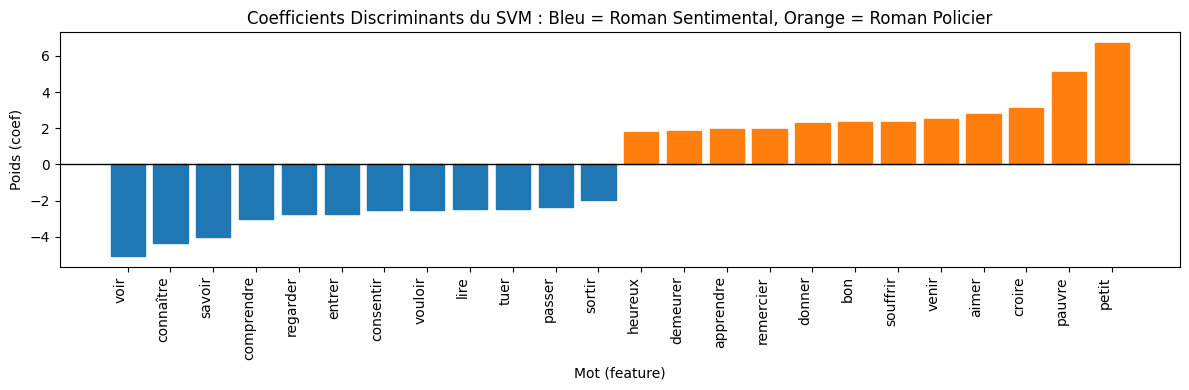

In [15]:
TARGET = "sentimental"
neg, pos = top_terms_for_class(clf, classes, feature_names, TARGET, k=12)

# Concat pour un seul axe des x
plot_df = pd.concat([neg, pos], ignore_index=True)

plt.figure(figsize=(12, 4))
bars = plt.bar(plot_df["feature"], plot_df["weight"])
plt.axhline(0, linewidth=1, color="black")

plt.title("Coefficients Discriminants du SVM : Bleu = Roman Sentimental, Orange = Roman Policier")
plt.xlabel("Mot (feature)")
plt.ylabel("Poids (coef)")

# Legende (codes couleur simples)
for b, s in zip(bars, plot_df["sign"]):
    if s.startswith("anti-"):
        b.set_color("tab:blue")
    else:
        b.set_color("tab:orange")

plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()
